In [1]:
%pip install numpy
%pip install pandas
import numpy as np
import pandas as pd
import os

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
base = os.getcwd()
print(base)


c:\Users\priya\OneDrive\Desktop\SmsSpam


In [3]:
df = pd.read_csv("spam.csv", encoding='cp1252')

In [4]:
df.sample(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
197,ham,is your hamster dead? Hey so tmr i meet you at...,NaN,NaN,NaN
3843,ham,"Yeah that's what I thought, lemme know if anyt...",NaN,NaN,NaN
96,ham,Watching telugu movie..wat abt u?,NaN,NaN,NaN
1059,spam,EASTENDERS TV Quiz. What FLOWER does DOT compa...,NaN,NaN,NaN
4000,ham,He's just gonna worry for nothing. And he won'...,NaN,NaN,NaN


In [5]:
df.shape

(5572, 5)

In [6]:
#data cleaning
#eda
# text preprovessing 
#model building 
#evaluation
#improvemnt
#website
#deploy

### DATA CLEANING


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   v1          5572 non-null   str  
 1   v2          5572 non-null   str  
 2   Unnamed: 2  50 non-null     str  
 3   Unnamed: 3  12 non-null     str  
 4   Unnamed: 4  6 non-null      str  
dtypes: str(5)
memory usage: 217.8 KB


In [8]:
# drop last three col
df = df.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'])

In [9]:
#renaming columns 
df = df.rename(columns={'v1' : 'target', 'v2': 'text'})
df.sample(5)

,target,text
2734,ham,Can you do a mag meeting this avo at some point?
4487,ham,Call me when you get the chance plz &lt;3
3531,ham,"Actually, my mobile is full of msg. And i m do..."
5313,ham,My sister going to earn more than me da.
1308,ham,I jokin oni lar.. ÌÏ busy then i wun disturb Ì_.


In [10]:
#label encoding
%pip install scikit-learn 
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [11]:
df['target'] = encoder.fit_transform(df['target'])
df.sample(5)

,target,text
1692,0,Weightloss! No more girl friends. Make loads o...
1290,0,Eat jap done oso aft ur lect wat... ÌÏ got lec...
3473,0,", how's things? Just a quick question."
3943,0,"Until 545 lor... Ya, can go 4 dinner together..."
2061,0,Hey ! I want you ! I crave you ! I miss you ! ...


In [12]:
#missing values 
df.isnull().sum()

target    0
text      0
dtype: int64

In [13]:
df.duplicated().sum()

np.int64(403)

In [14]:
df = df.drop_duplicates(keep='first')

In [15]:
df.shape

(5169, 2)

### EDA

In [16]:
# kinta percent spam hai aur kitna ham 
df['target'].value_counts()

target
0    4516
1     653
Name: count, dtype: int64


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


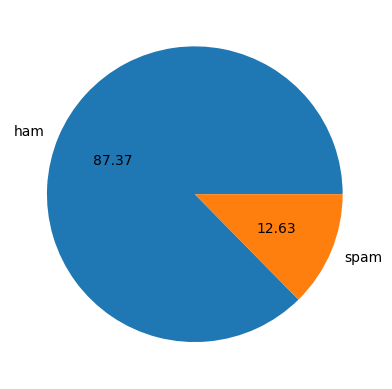

In [17]:
%pip install matplotlib
import matplotlib.pyplot as plt 
plt.pie(df['target'].value_counts(),labels=['ham','spam'],autopct="%0.2f")
plt.show()

In [18]:
#DATA is imbalanced  beacuse of low spam and 

In [19]:
#kitne alaphabets , kitne char , words ,sentensce
%pip install nltk


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [20]:
import nltk
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\priya\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [21]:
#kitne len hai vo text ki 
df['number_of_characters'] = df['text'].apply(len) 

In [22]:
df.head()

,target,text,number_of_characters
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [23]:
#no of words 
df['number_of_words']=(df['text'].apply(lambda x: len(nltk.word_tokenize(x)) ))

In [24]:
df.head()

,target,text,number_of_characters,number_of_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [25]:
#number of sentences 
df['number_of_sentences'] = df['text'].apply(lambda x : len(nltk.sent_tokenize(x)))

In [26]:
df.head()

,target,text,number_of_characters,number_of_words,number_of_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [27]:
df.describe()

,target,number_of_characters,number_of_words,number_of_sentences
count,5169.000000,5169.000000,5169.000000,5169.000000
mean,0.126330,78.977945,18.455794,1.965564
std,0.332253,58.236293,13.324758,1.448541
min,0.000000,2.000000,1.000000,1.000000
25%,0.000000,36.000000,9.000000,1.000000
50%,0.000000,60.000000,15.000000,1.000000
75%,0.000000,117.000000,26.000000,2.000000
max,1.000000,910.000000,220.000000,38.000000


In [28]:
df[df['target']==0].describe()

,target,number_of_characters,number_of_words,number_of_sentences
count,4516.0,4516.000000,4516.000000,4516.000000
mean,0.0,70.459256,17.123782,1.820195
std,0.0,56.358207,13.493970,1.383657
min,0.0,2.000000,1.000000,1.000000
25%,0.0,34.000000,8.000000,1.000000
50%,0.0,52.000000,13.000000,1.000000
75%,0.0,90.000000,22.000000,2.000000
max,0.0,910.000000,220.000000,38.000000


In [29]:
df[df['target']==1].describe()

,target,number_of_characters,number_of_words,number_of_sentences
count,653.0,653.000000,653.000000,653.000000
mean,1.0,137.891271,27.667688,2.970904
std,0.0,30.137753,7.008418,1.488425
min,1.0,13.000000,2.000000,1.000000
25%,1.0,132.000000,25.000000,2.000000
50%,1.0,149.000000,29.000000,3.000000
75%,1.0,157.000000,32.000000,4.000000
max,1.0,224.000000,46.000000,9.000000


In [30]:
# we cann see that spam messages are longer 
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [31]:
import seaborn as sns

<Axes: xlabel='number_of_characters', ylabel='Count'>

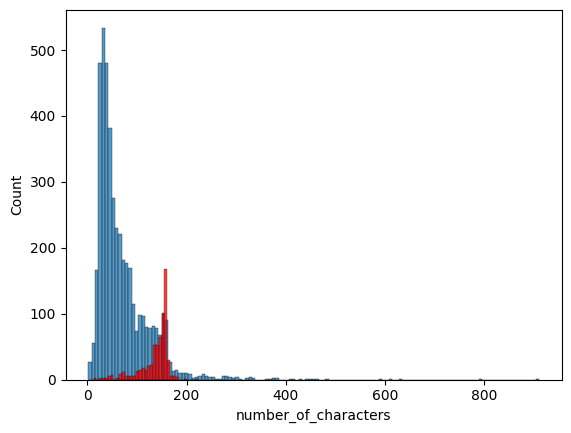

In [32]:
sns.histplot(df[df['target']==0]['number_of_characters'])
sns.histplot(df[df['target']==1]['number_of_characters'],color='red')

<Axes: xlabel='number_of_words', ylabel='Count'>

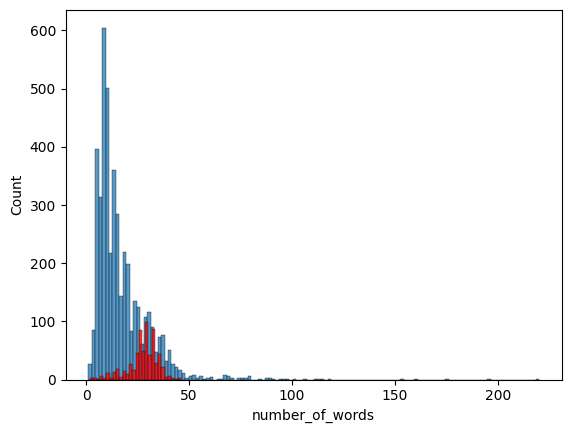

In [33]:
sns.histplot(df[df['target']==0]['number_of_words'])
sns.histplot(df[df['target']==1]['number_of_words'],color='red')

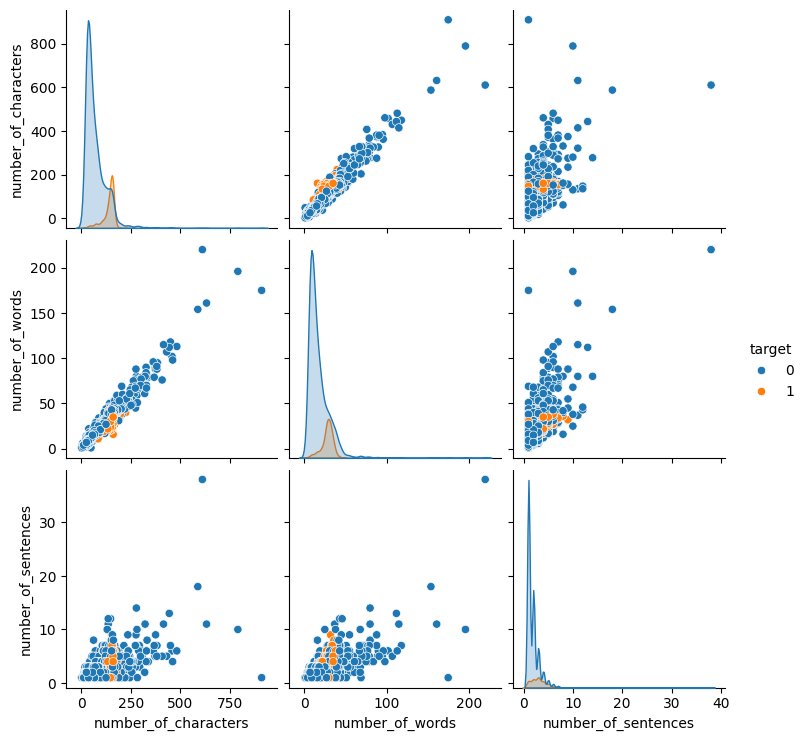

In [34]:
#co relation btw columns
sns.pairplot(df,hue='target')

<Axes: >

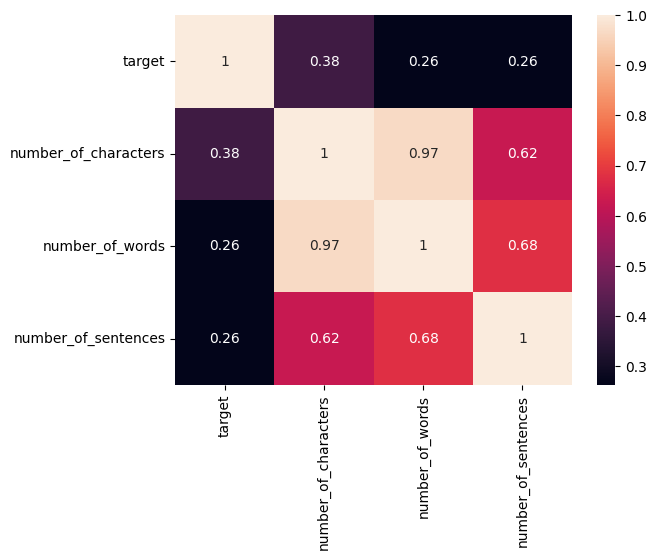

In [35]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

# DATA Preprocessing 


In [40]:
#lower case 
#tokenization
#removing special characters
#removing stop words and punctuations
#stemming 

from nltk.corpus import stopwords
import nltk
nltk.download('stopwords')

from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()
import string

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\priya\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [41]:
def transform_text(text):
    text = text.lower()
    text = nltk.word_tokenize(text)
    y  = []
    
    for i in text :
        if i.isalnum():
            y.append(i)

    text = y[:]  # we need to clone if we to text = y , than new is not made so if we clear y , than text is also cleared  
    y.clear()

    for i in text :
        if i not in stopwords.words('english') and i not in string.punctuation :
            y.append(ps.stem(i))
    return y

In [42]:
transform_text('hi i am how are greating , inform delhi  you , ilv!! !!,, m')

['hi', 'great', 'inform', 'delhi', 'ilv']

In [44]:
df['transformed_text'] =df['text'].apply(transform_text)

In [46]:
%pip install wordcloud

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [47]:
from wordcloud import WordCloud
wc = WordCloud()

In [50]:
# Create a temporary series to avoid SettingWithCopyWarning if it's a slice
spam_text = df[df['target']==1]['transformed_text'].astype(str)

# Now apply str.cat
spam_wc = wc.generate(spam_text.str.cat(sep=" "))


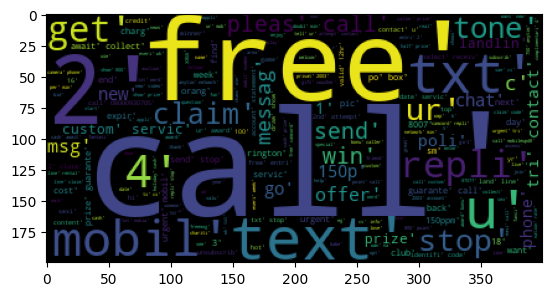

In [51]:
plt.imshow(spam_wc)

In [52]:
df.head()

,target,text,number_of_characters,number_of_words,number_of_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,"[go, jurong, point, crazi, avail, bugi, n, gre..."
1,0,Ok lar... Joking wif u oni...,29,8,2,"[ok, lar, joke, wif, u, oni]"
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,"[free, entri, 2, wkli, comp, win, fa, cup, fin..."
3,0,U dun say so early hor... U c already then say...,49,13,1,"[u, dun, say, earli, hor, u, c, alreadi, say]"
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,"[nah, think, goe, usf, live, around, though]"
